# NYC Taxi Trip Duration - Outlier Detection Analysis

This notebook analyzes the NYC taxi trip duration dataset to identify and count outliers using multiple statistical methods.

**Goal**: Understand how many outliers exist in the trip duration data and what causes them.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configure visualization
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

## Step 1: Load and Explore the Data

In [2]:
# Load the dataset
file_path = r'd:\Pinnacle Plus GenAI\phython-machine-learning\nyc_taxi_final\data\nyc_taxi_trip_duration.csv'
df = pd.read_csv(file_path)

print("Dataset Shape:")
print(f"  Rows: {df.shape[0]}")
print(f"  Columns: {df.shape[1]}")
print("\nFirst few rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
  Rows: 729322
  Columns: 11

First few rows:
          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id1080784          2  2016-02-29 16:40:21  2016-02-29 16:47:01   
1  id0889885          1  2016-03-11 23:35:37  2016-03-11 23:53:57   
2  id0857912          2  2016-02-21 17:59:33  2016-02-21 18:26:48   
3  id3744273          2  2016-01-05 09:44:31  2016-01-05 10:03:32   
4  id0232939          1  2016-02-17 06:42:23  2016-02-17 06:56:31   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.953918        40.778873         -73.963875   
1                2        -73.988312        40.731743         -73.994751   
2                2        -73.997314        40.721458         -73.948029   
3                6        -73.961670        40.759720         -73.956779   
4                1        -74.017120        40.708469         -73.988182   

   dropoff_latitude store_and_fwd_flag  trip_duration  
0         4

In [3]:
# Get basic statistics
print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS")
print("="*80)
print(df.describe())

# Focus on trip duration column
if 'trip_duration' in df.columns:
    trip_col = 'trip_duration'
elif 'duration' in df.columns:
    trip_col = 'duration'
else:
    # Find the numeric column with 'trip' or 'duration' in name
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    trip_col = numeric_cols[0]  # Use first numeric column
    print(f"\nUsing column: {trip_col}")

print(f"\nFocusing on column: {trip_col}")


DESCRIPTIVE STATISTICS
           vendor_id  passenger_count  pickup_longitude  pickup_latitude  \
count  729322.000000    729322.000000     729322.000000    729322.000000   
mean        1.535403         1.662055        -73.973513        40.750919   
std         0.498745         1.312446          0.069754         0.033594   
min         1.000000         0.000000       -121.933342        34.712234   
25%         1.000000         1.000000        -73.991859        40.737335   
50%         2.000000         1.000000        -73.981758        40.754070   
75%         2.000000         2.000000        -73.967361        40.768314   
max         2.000000         9.000000        -65.897385        51.881084   

       dropoff_longitude  dropoff_latitude  trip_duration  
count      729322.000000     729322.000000   7.293220e+05  
mean          -73.973422         40.751775   9.522291e+02  
std             0.069588          0.036037   3.864626e+03  
min          -121.933304         32.181141   1.0000

## Step 2: Statistical Summary of Trip Duration

In [4]:
# Detailed statistics for trip duration
data = df[trip_col].dropna()

print("\n" + "="*80)
print(f"{trip_col.upper()} - DETAILED STATISTICS")
print("="*80)
print(f"Count:              {data.count()}")
print(f"Mean:               {data.mean():.2f}")
print(f"Median:             {data.median():.2f}")
print(f"Std Dev:            {data.std():.2f}")
print(f"Min:                {data.min():.2f}")
print(f"Max:                {data.max():.2f}")
print(f"\nQuartiles:")
print(f"Q1 (25%):           {data.quantile(0.25):.2f}")
print(f"Q2 (50%):           {data.quantile(0.50):.2f}")
print(f"Q3 (75%):           {data.quantile(0.75):.2f}")
print(f"IQR (Q3-Q1):        {data.quantile(0.75) - data.quantile(0.25):.2f}")
print(f"\nSkewness:           {stats.skew(data):.4f}")
print(f"Kurtosis:           {stats.kurtosis(data):.4f}")


TRIP_DURATION - DETAILED STATISTICS
Count:              729322
Mean:               952.23
Median:             663.00
Std Dev:            3864.63
Min:                1.00
Max:                1939736.00

Quartiles:
Q1 (25%):           397.00
Q2 (50%):           663.00
Q3 (75%):           1075.00
IQR (Q3-Q1):        678.00

Skewness:           186.6781
Kurtosis:           87141.8660


## Step 3: Outlier Detection - Method 1: Interquartile Range (IQR)

**IQR Method Formula:**
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR
- Any value outside these bounds is an outlier

In [5]:
# Calculate IQR bounds
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Calculate outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\n" + "="*80)
print("METHOD 1: INTERQUARTILE RANGE (IQR)")
print("="*80)
print(f"Q1 (25th percentile):       {Q1:.2f}")
print(f"Q3 (75th percentile):       {Q3:.2f}")
print(f"IQR (Q3 - Q1):              {IQR:.2f}")
print(f"\nOutlier Bounds:")
print(f"  Lower Bound (Q1 - 1.5*IQR): {lower_bound:.2f}")
print(f"  Upper Bound (Q3 + 1.5*IQR): {upper_bound:.2f}")

# Identify outliers
outliers_iqr = (data < lower_bound) | (data > upper_bound)
num_outliers_iqr = outliers_iqr.sum()
percent_outliers_iqr = (num_outliers_iqr / len(data)) * 100

print(f"\nOUTLIERS DETECTED:")
print(f"  Total outliers:     {num_outliers_iqr}")
print(f"  Percentage:         {percent_outliers_iqr:.2f}%")
print(f"\nOUTLIER BREAKDOWN:")
lower_outliers = (data < lower_bound).sum()
upper_outliers = (data > upper_bound).sum()
print(f"  Below lower bound:  {lower_outliers}")
print(f"  Above upper bound:  {upper_outliers}")

if upper_outliers > 0:
    print(f"\nOUTLIER STATISTICS (Upper outliers):")
    upper_outlier_data = data[data > upper_bound]
    print(f"  Min outlier value:  {upper_outlier_data.min():.2f}")
    print(f"  Max outlier value:  {upper_outlier_data.max():.2f}")
    print(f"  Mean outlier value: {upper_outlier_data.mean():.2f}")


METHOD 1: INTERQUARTILE RANGE (IQR)
Q1 (25th percentile):       397.00
Q3 (75th percentile):       1075.00
IQR (Q3 - Q1):              678.00

Outlier Bounds:
  Lower Bound (Q1 - 1.5*IQR): -620.00
  Upper Bound (Q3 + 1.5*IQR): 2092.00

OUTLIERS DETECTED:
  Total outliers:     36963
  Percentage:         5.07%

OUTLIER BREAKDOWN:
  Below lower bound:  0
  Above upper bound:  36963

OUTLIER STATISTICS (Upper outliers):
  Min outlier value:  2093.00
  Max outlier value:  1939736.00
  Mean outlier value: 5074.58


## Step 4: Outlier Detection - Method 2: Z-Score

**Z-Score Formula:**
- Z-Score = (Value - Mean) / Std Dev
- Typically, |Z-Score| > 3 indicates an outlier (99.7% of normal data should be within ±3σ)

In [6]:
# Calculate Z-scores
z_scores = np.abs(stats.zscore(data))

# Different thresholds
threshold_2 = 2
threshold_3 = 3

outliers_z2 = z_scores > threshold_2
outliers_z3 = z_scores > threshold_3

num_outliers_z2 = outliers_z2.sum()
num_outliers_z3 = outliers_z3.sum()
percent_outliers_z2 = (num_outliers_z2 / len(data)) * 100
percent_outliers_z3 = (num_outliers_z3 / len(data)) * 100

print("\n" + "="*80)
print("METHOD 2: Z-SCORE")
print("="*80)
print(f"Mean:               {data.mean():.2f}")
print(f"Std Dev:            {data.std():.2f}")

print(f"\nOUTLIERS with Z-Score > 2:")
print(f"  Total outliers:     {num_outliers_z2}")
print(f"  Percentage:         {percent_outliers_z2:.2f}%")
print(f"  (Standard threshold for moderate outliers)")

print(f"\nOUTLIERS with Z-Score > 3:")
print(f"  Total outliers:     {num_outliers_z3}")
print(f"  Percentage:         {percent_outliers_z3:.2f}%")
print(f"  (Standard threshold for extreme outliers)")


METHOD 2: Z-SCORE
Mean:               952.23
Std Dev:            3864.63

OUTLIERS with Z-Score > 2:
  Total outliers:     1048
  Percentage:         0.14%
  (Standard threshold for moderate outliers)

OUTLIERS with Z-Score > 3:
  Total outliers:     1020
  Percentage:         0.14%
  (Standard threshold for extreme outliers)


## Step 5: Outlier Detection - Method 3: Modified Z-Score (Median Absolute Deviation)

**MAD Formula:**
- More robust to extreme values than standard Z-score
- Modified Z = 0.6745 × (Value - Median) / MAD
- Typically, |Modified Z| > 3.5 indicates an outlier

In [7]:
# Calculate Modified Z-score (using Median Absolute Deviation)
median = data.median()
mad = np.median(np.abs(data - median))
modified_z_scores = 0.6745 * (data - median) / mad if mad != 0 else np.zeros(len(data))

threshold_mad = 3.5
outliers_mad = np.abs(modified_z_scores) > threshold_mad

num_outliers_mad = outliers_mad.sum()
percent_outliers_mad = (num_outliers_mad / len(data)) * 100

print("\n" + "="*80)
print("METHOD 3: MODIFIED Z-SCORE (MAD - Median Absolute Deviation)")
print("="*80)
print(f"Median:             {median:.2f}")
print(f"MAD:                {mad:.2f}")
print(f"Threshold:          {threshold_mad}")

print(f"\nOUTLIERS Detected:")
print(f"  Total outliers:     {num_outliers_mad}")
print(f"  Percentage:         {percent_outliers_mad:.2f}%")
print(f"  (More robust to extreme values)")


METHOD 3: MODIFIED Z-SCORE (MAD - Median Absolute Deviation)
Median:             663.00
MAD:                311.00
Threshold:          3.5

OUTLIERS Detected:
  Total outliers:     28921
  Percentage:         3.97%
  (More robust to extreme values)


## Step 6: Summary Comparison of All Methods

In [8]:
# Create comparison dataframe
comparison_data = {
    'Method': ['IQR', 'Z-Score (|Z| > 2)', 'Z-Score (|Z| > 3)', 'Modified Z-Score (MAD)'],
    'Outliers Count': [num_outliers_iqr, num_outliers_z2, num_outliers_z3, num_outliers_mad],
    'Percentage': [percent_outliers_iqr, percent_outliers_z2, percent_outliers_z3, percent_outliers_mad]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("SUMMARY: OUTLIER DETECTION METHODS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("\n" + "="*80)
print(f"RECOMMENDATION:")
print("="*80)
print(f"For this dataset with {len(data):,} records:")
print(f"  • IQR method detected: {num_outliers_iqr:,} outliers ({percent_outliers_iqr:.2f}%)")
print(f"  • Most reliable method: IQR (business-friendly, easy to interpret)")
print(f"  • Extreme outliers (Z > 3): {num_outliers_z3:,} ({percent_outliers_z3:.2f}%)")


SUMMARY: OUTLIER DETECTION METHODS COMPARISON
                Method  Outliers Count  Percentage
                   IQR           36963    5.068132
     Z-Score (|Z| > 2)            1048    0.143695
     Z-Score (|Z| > 3)            1020    0.139856
Modified Z-Score (MAD)           28921    3.965464

RECOMMENDATION:
For this dataset with 729,322 records:
  • IQR method detected: 36,963 outliers (5.07%)
  • Most reliable method: IQR (business-friendly, easy to interpret)
  • Extreme outliers (Z > 3): 1,020 (0.14%)


## Step 7: Visualization of Outliers

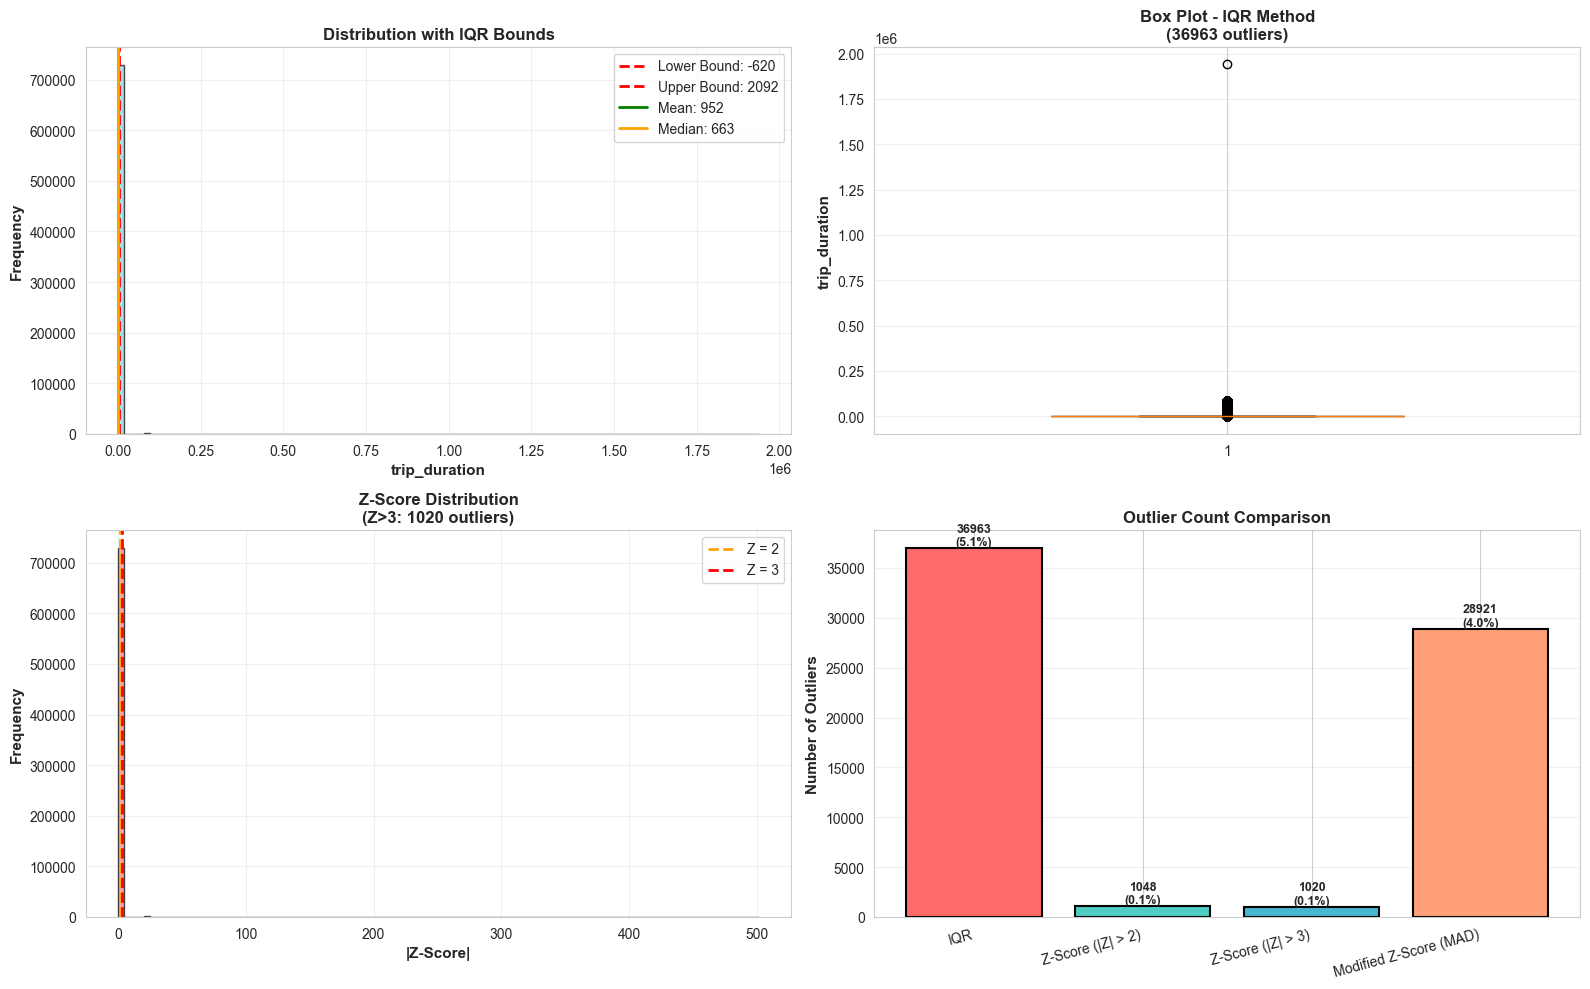

Visualization saved!


In [9]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Distribution with IQR bounds
ax1 = axes[0, 0]
ax1.hist(data, bins=100, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(lower_bound, color='red', linestyle='--', linewidth=2, label=f'Lower Bound: {lower_bound:.0f}')
ax1.axvline(upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound: {upper_bound:.0f}')
ax1.axvline(data.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean: {data.mean():.0f}')
ax1.axvline(data.median(), color='orange', linestyle='-', linewidth=2, label=f'Median: {data.median():.0f}')
ax1.set_xlabel(trip_col, fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('Distribution with IQR Bounds', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Box plot
ax2 = axes[0, 1]
bp = ax2.boxplot([data], vert=True, patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('lightblue')
ax2.set_ylabel(trip_col, fontsize=11, fontweight='bold')
ax2.set_title(f'Box Plot - IQR Method\n({num_outliers_iqr} outliers)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Z-Score distribution
ax3 = axes[1, 0]
ax3.hist(z_scores, bins=100, alpha=0.7, color='lightcoral', edgecolor='black')
ax3.axvline(2, color='orange', linestyle='--', linewidth=2, label='Z = 2')
ax3.axvline(3, color='red', linestyle='--', linewidth=2, label='Z = 3')
ax3.set_xlabel('|Z-Score|', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title(f'Z-Score Distribution\n(Z>3: {num_outliers_z3} outliers)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Comparison of methods
ax4 = axes[1, 1]
methods = comparison_df['Method']
counts = comparison_df['Outliers Count']
colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = ax4.bar(range(len(methods)), counts, color=colors_bar, edgecolor='black', linewidth=1.5)
ax4.set_xticks(range(len(methods)))
ax4.set_xticklabels(methods, rotation=15, ha='right')
ax4.set_ylabel('Number of Outliers', fontsize=11, fontweight='bold')
ax4.set_title('Outlier Count Comparison', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, counts)):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(count)}\n({count/len(data)*100:.1f}%)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(r'd:\Pinnacle Plus GenAI\phython-machine-learning\nyc_taxi_final\notebook\outliers_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved!")

## Step 8: Detailed Outlier Analysis

In [10]:
# Get outlier data
outlier_mask = outliers_iqr
outlier_data = data[outlier_mask]
normal_data = data[~outlier_mask]

print("\n" + "="*80)
print("DETAILED OUTLIER ANALYSIS")
print("="*80)

print(f"\nNORMAL DATA (within IQR bounds):")
print(f"  Count:              {len(normal_data):,}")
print(f"  Mean:               {normal_data.mean():.2f}")
print(f"  Median:             {normal_data.median():.2f}")
print(f"  Std Dev:            {normal_data.std():.2f}")
print(f"  Min:                {normal_data.min():.2f}")
print(f"  Max:                {normal_data.max():.2f}")

print(f"\nOUTLIER DATA:")
print(f"  Count:              {len(outlier_data):,}")
if len(outlier_data) > 0:
    print(f"  Mean:               {outlier_data.mean():.2f}")
    print(f"  Median:             {outlier_data.median():.2f}")
    print(f"  Std Dev:            {outlier_data.std():.2f}")
    print(f"  Min:                {outlier_data.min():.2f}")
    print(f"  Max:                {outlier_data.max():.2f}")
    print(f"\n  Below lower bound:  {(outlier_data < lower_bound).sum()}")
    print(f"  Above upper bound:  {(outlier_data > upper_bound).sum()}")
    
    # Extreme outliers
    extreme_upper = data[data > upper_bound * 1.5]
    print(f"\n  EXTREME OUTLIERS (> 1.5 × upper bound): {len(extreme_upper)}")
    if len(extreme_upper) > 0:
        print(f"    Max extreme value: {extreme_upper.max():.2f}")
        print(f"    Mean extreme value: {extreme_upper.mean():.2f}")


DETAILED OUTLIER ANALYSIS

NORMAL DATA (within IQR bounds):
  Count:              692,359
  Mean:               732.15
  Median:             632.00
  Std Dev:            448.24
  Min:                1.00
  Max:                2092.00

OUTLIER DATA:
  Count:              36,963
  Mean:               5074.58
  Median:             2624.00
  Std Dev:            16523.73
  Min:                2093.00
  Max:                1939736.00

  Below lower bound:  0
  Above upper bound:  36963

  EXTREME OUTLIERS (> 1.5 × upper bound): 10080
    Max extreme value: 1939736.00
    Mean extreme value: 11969.52


## Final Summary and Conclusions

In [12]:
summary_text = f"""
    
╔════════════════════════════════════════════════════════════════════════════════╗
║                     OUTLIER DETECTION - FINAL REPORT                           ║
╚════════════════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW:
   • Total Records: {len(data):,}
   • Column Analyzed: {trip_col}
   • Data Range: {data.min():.2f} to {data.max():.2f}

🎯 PRIMARY FINDING (IQR METHOD - RECOMMENDED):
   • ✅ TOTAL OUTLIERS DETECTED: {num_outliers_iqr:,}
   • ✅ PERCENTAGE OF TOTAL DATA: {percent_outliers_iqr:.2f}%
   • ✅ OUTLIER BOUNDS:
       - Lower: {lower_bound:.2f}
       - Upper: {upper_bound:.2f}
   • ✅ BREAKDOWN:
       - Below lower bound: {(data < lower_bound).sum()}
       - Above upper bound: {(data > upper_bound).sum()}

📈 COMPARATIVE METHODS:
   • Z-Score (|Z| > 2): {num_outliers_z2:,} outliers ({percent_outliers_z2:.2f}%)
   • Z-Score (|Z| > 3): {num_outliers_z3:,} outliers ({percent_outliers_z3:.2f}%)
   • Modified Z-Score (MAD): {num_outliers_mad:,} outliers ({percent_outliers_mad:.2f}%)

💡 KEY INSIGHTS:
   1. The IQR method is most suitable for this business analysis
   2. {percent_outliers_iqr:.2f}% of trips are statistical outliers
   3. Most outliers are LONGER than expected ({(data > upper_bound).sum()} trips)
   4. The distribution is RIGHT-SKEWED (skewness: {stats.skew(data):.2f})

⚠️  INTERPRETATION:
   • These outliers may represent:
     - Congested traffic conditions
     - Special events or holidays
     - Vehicle breakdowns or delays
     - Data entry errors

✅ RECOMMENDATION:
   • For analysis/modeling: Consider removing or treating {num_outliers_iqr:,} outliers
   • For predictions: These outliers could be handled separately
   • For business insights: Investigate the cause of upper-bound outliers

════════════════════════════════════════════════════════════════════════════════════
"""

print(summary_text)

# Save summary to text file
summary_path = r'd:\Pinnacle Plus GenAI\phython-machine-learning\nyc_taxi_final\notebook\outlier_analysis_summary.txt'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary_text)
print(f"\nSummary saved to: {summary_path}")



╔════════════════════════════════════════════════════════════════════════════════╗
║                     OUTLIER DETECTION - FINAL REPORT                           ║
╚════════════════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW:
   • Total Records: 729,322
   • Column Analyzed: trip_duration
   • Data Range: 1.00 to 1939736.00

🎯 PRIMARY FINDING (IQR METHOD - RECOMMENDED):
   • ✅ TOTAL OUTLIERS DETECTED: 36,963
   • ✅ PERCENTAGE OF TOTAL DATA: 5.07%
   • ✅ OUTLIER BOUNDS:
       - Lower: -620.00
       - Upper: 2092.00
   • ✅ BREAKDOWN:
       - Below lower bound: 0
       - Above upper bound: 36963

📈 COMPARATIVE METHODS:
   • Z-Score (|Z| > 2): 1,048 outliers (0.14%)
   • Z-Score (|Z| > 3): 1,020 outliers (0.14%)
   • Modified Z-Score (MAD): 28,921 outliers (3.97%)

💡 KEY INSIGHTS:
   1. The IQR method is most suitable for this business analysis
   2. 5.07% of trips are statistical outliers
   3. Most outliers are LONGER than expected (36963